In [1]:
import kagglehub
import pandas as pd
import numpy as np
import os

# Download dataset
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
print("Path:", path)

# Load CSV
file_path = os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv")
df = pd.read_csv(file_path)

df.head()

c:\Users\gurra\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path: C:\Users\gurra\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')

# Drop missing values
df.dropna(inplace=True)

# Drop customerID (not useful)
df.drop("customerID", axis=1, inplace=True)

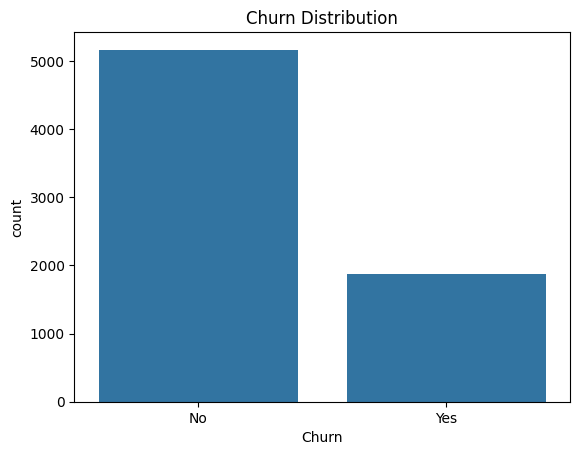

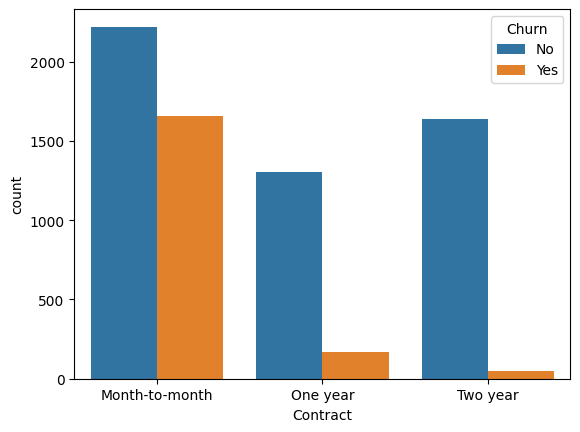

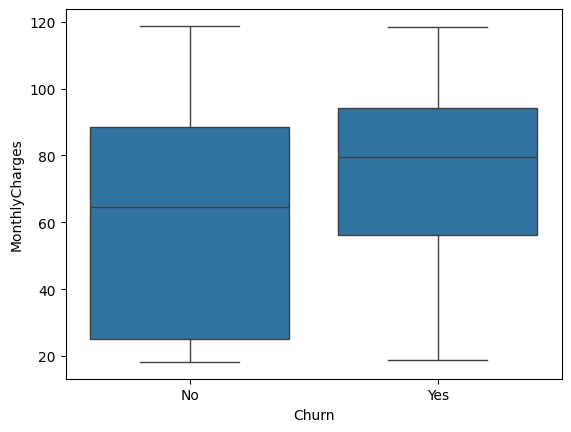

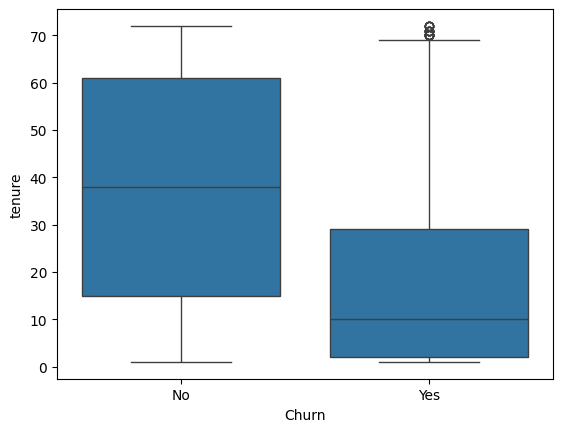

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Churn distribution
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

# Contract vs Churn
sns.countplot(x="Contract", hue="Churn", data=df)
plt.show()

# Monthly Charges vs Churn
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.show()

# Tenure vs Churn
sns.boxplot(x="Churn", y="tenure", data=df)
plt.show()

In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [5]:
from sklearn.model_selection import train_test_split

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

def build_model(hidden_layers):
    model = Sequential()
    
    model.add(Dense(32, activation='relu', input_dim=X_train.shape[1]))
    
    for units in hidden_layers:
        model.add(Dense(units, activation='relu'))
    
    model.add(Dense(1, activation='sigmoid'))
    
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

In [8]:
configs = {
    "2_layers": [32, 16],
    "3_layers": [64, 32, 16],
    "5_layers": [128, 64, 32, 16, 8]
}

results = {}
models = {}

In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

for name, layers in configs.items():
    print(f"Training {name}...")
    
    model = build_model(layers)
    
    model.fit(
        X_train, y_train,
        epochs=20,
        batch_size=32,
        verbose=0
    )
    
    y_pred = (model.predict(X_test) > 0.5).astype(int)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    
    results[name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec
    }
    
    models[name] = model

Training 2_layers...


c:\Users\gurra\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Training 3_layers...


c:\Users\gurra\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Training 5_layers...


c:\Users\gurra\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [10]:
print("\nModel Comparison:")
for name, metrics in results.items():
    print(f"\n{name}")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")


Model Comparison:

2_layers
Accuracy: 0.7790
Precision: 0.5963
Recall: 0.5214

3_layers
Accuracy: 0.7790
Precision: 0.6171
Recall: 0.4439

5_layers
Accuracy: 0.7434
Precision: 0.5157
Recall: 0.5695


In [11]:
# Select best model based on accuracy
best_model_name = max(results, key=lambda x: results[x]["Accuracy"])
best_model = models[best_model_name]

print("Best Model:", best_model_name)

# Save model
best_model.save("churn_model.keras")

# Save scaler
import pickle
pickle.dump(scaler, open("scaler.pkl", "wb"))

Best Model: 2_layers


In [12]:
columns = X.columns
pickle.dump(columns, open("columns.pkl", "wb"))